# MFIS $_{t-1} \rightarrow$ MFIS $_t$

In [17]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.evaluation import Evaluation
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.core.data_transforms import Transform
from src.model import DMORandomForestRegressor
from src.train import XVRandomForest

import numpy as np
import torch

In [2]:
K_FOLDS = 5
N_VISITS = 4

In [3]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [4]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [6]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [7]:
# remove missing labels
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [8]:
fatigue_value = dmo_labels

In [9]:
fatigue_value.shape

torch.Size([428, 4, 1])

In [10]:
fatigue_value = fatigue_value.flatten(start_dim=1, end_dim=2)

In [11]:
fatigue_value.shape

torch.Size([428, 4])

In [12]:
# Min max normalise all fatigue values
physical_subset_max = 36
fatigue_value = fatigue_value / physical_subset_max

In [13]:
fatigue_input = fatigue_value[:, :-1]
fatigue_input = fatigue_input.unsqueeze(dim=2)
fatigue_input = fatigue_input.flatten(start_dim=0, end_dim=1)
fatigue_input.shape

torch.Size([1284, 1])

In [14]:
fatigue_label = fatigue_value[:, 1:]
fatigue_label = fatigue_label.flatten(start_dim=0, end_dim=1)
fatigue_label.shape

torch.Size([1284])

In [15]:
# shuffle
patients, *other = fatigue_input.shape
generator = torch.Generator()
generator.manual_seed(1234)
random_permutation = torch.randperm(patients, generator=generator)

fatigue_input = fatigue_input[random_permutation]
fatigue_label = fatigue_label[random_permutation]

In [18]:
fatigue_input_split = torch.tensor_split(fatigue_input, K_FOLDS)
fatigue_label_split = torch.tensor_split(fatigue_label, K_FOLDS)

prediction_arr = []
actual_arr = []
for split_i in range(K_FOLDS):
    test_label = fatigue_label_split[split_i]
    test_data = fatigue_input_split[split_i]

    train_label = torch.cat(
        [fatigue_label_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    train_data = torch.cat(
        [fatigue_input_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    
    rf_model = DMORandomForestRegressor(n_trees=500)

    rf_model.train(train_data, train_label)
    score = rf_model.score(test_data, test_label)
    print(score)
    
    prediction = torch.tensor(rf_model.predict(test_data))
    prediction = (prediction * physical_subset_max)
    
    actual = (test_label * physical_subset_max)
    
    prediction_arr.append(prediction)
    actual_arr.append(actual)

0.5558386516447098
0.6290603110133917
0.5583024562804089
0.5414433537035694
0.5543728274686277


In [19]:
prediction = torch.cat(prediction_arr)
actual = torch.cat(actual_arr)

{'accuracy': 0.01791277258566978, 'Mean Squared Error': 29.877880096435547, 'Mean Absolute Error': 4.221718788146973, 'R^2': 0.5680817079679059}


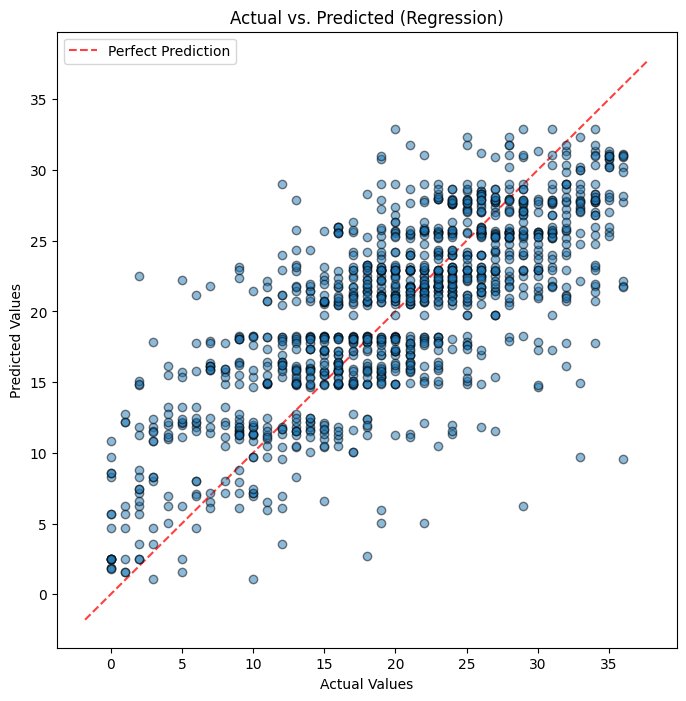

In [20]:
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()